In [13]:
import pandas as pd

# Ganti nama_file_mobil.csv dengan nama file aslimu
df = pd.read_csv('jdm_used_cars.csv') 
df.head()

,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,0,80,nissan,march,2003,80000,1240,at,2wd,rhd,gasoline
1,1,110,nissan,march,2010,53000,1200,at,2wd,rhd,gasoline
2,2,165,nissan,lafesta,2005,47690,2000,at,2wd,rhd,gasoline
3,3,190,toyota,avensis,2008,130661,1990,at,2wd,rhd,gasoline
4,4,190,daihatsu,mira,2006,66300,660,at,2wd,rhd,gasoline


In [14]:
# Menampilkan dimensi dataset (baris, kolom)
print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Menampilkan 5 baris pertama dan 5 baris sampel acak
display(df.head())
display(df.sample(5, random_state=42))

Dimensi dataset: 2318 baris, 11 kolom


,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,0,80,nissan,march,2003,80000,1240,at,2wd,rhd,gasoline
1,1,110,nissan,march,2010,53000,1200,at,2wd,rhd,gasoline
2,2,165,nissan,lafesta,2005,47690,2000,at,2wd,rhd,gasoline
3,3,190,toyota,avensis,2008,130661,1990,at,2wd,rhd,gasoline
4,4,190,daihatsu,mira,2006,66300,660,at,2wd,rhd,gasoline


,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
1040,1050,950,nissan,tiida,2011,73000,1500,at,2wd,rhd,gasoline
548,552,760,honda,fit,2005,78000,1330,at,2wd,rhd,gasoline
100,102,400,daihatsu,tanto,2012,183800,660,at,2wd,rhd,gasoline
1044,1054,950,toyota,brevis,2001,76000,2990,at,2wd,rhd,gasoline
251,255,560,honda,fit,2004,74200,1300,at,2wd,rhd,gasoline


In [15]:
# Mengecek tipe data setiap kolom dan memori yang digunakan
print("--- Informasi Dataset ---")
df.info()

# Menghitung persentase missing values per kolom
print("\n--- Persentase Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Total Kosong': missing_data, 'Persentase (%)': missing_percent})
display(missing_df[missing_df['Total Kosong'] > 0].sort_values(by='Persentase (%)', ascending=False))

--- Informasi Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Unnamed: 0       2318 non-null   int64
 1   price            2318 non-null   int64
 2   mark             2318 non-null   str  
 3   model            2318 non-null   str  
 4   year             2318 non-null   int64
 5   mileage          2318 non-null   int64
 6   engine_capacity  2318 non-null   int64
 7   transmission     2318 non-null   str  
 8   drive            2318 non-null   str  
 9   hand_drive       2318 non-null   str  
 10  fuel             2318 non-null   str  
dtypes: int64(5), str(6)
memory usage: 199.3 KB

--- Persentase Missing Values ---


,Total Kosong,Persentase (%)


In [16]:
# Mengecek dan menghapus duplikasi data (jika ada)
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {jumlah_duplikat}")

if jumlah_duplikat > 0:
    df = df.drop_duplicates(keep='first')
    print("Baris duplikat berhasil dihapus.")

# Melihat ringkasan statistik (fokus pada kolom numerik)
display(df.describe())

Jumlah baris duplikat: 0


,Unnamed: 0,price,year,mileage,engine_capacity
count,2318.000000,2318.000000,2318.000000,2318.000000,2318.000000
mean,1169.047023,971.522433,2005.972390,100013.194996,1507.010785
std,674.460724,288.673112,3.698863,52512.478883,549.585170
min,0.000000,80.000000,1979.000000,2000.000000,9.000000
25%,583.250000,776.000000,2004.000000,67000.000000,1300.000000
50%,1168.500000,1000.000000,2006.000000,94000.000000,1490.000000
75%,1753.750000,1213.000000,2009.000000,124000.000000,1800.000000
max,2335.000000,1400.000000,2015.000000,790000.000000,12340.000000


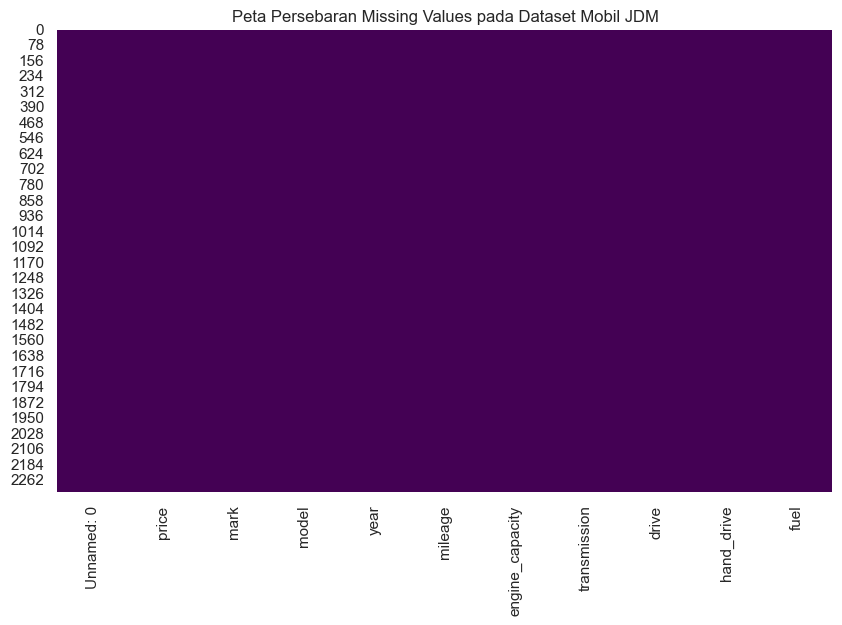

In [17]:
# Import library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi
sns.set_theme(style="whitegrid")

# Visualisasi Missing Values menggunakan Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Peta Persebaran Missing Values pada Dataset Mobil JDM')
plt.show()

Kolom 'Unnamed: 0' berhasil dihapus!


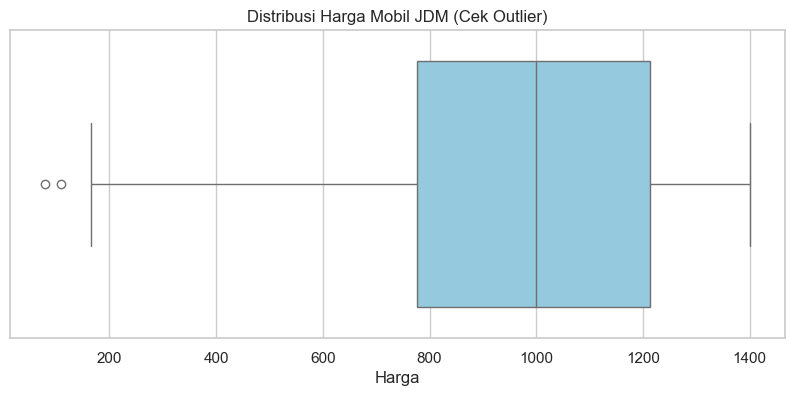

In [18]:
# 1. Menghapus kolom 'Unnamed: 0' karena tidak informatif
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Kolom 'Unnamed: 0' berhasil dihapus!")

# Melihat distribusi harga (price) menggunakan Boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Distribusi Harga Mobil JDM (Cek Outlier)')
plt.xlabel('Harga')
plt.show()

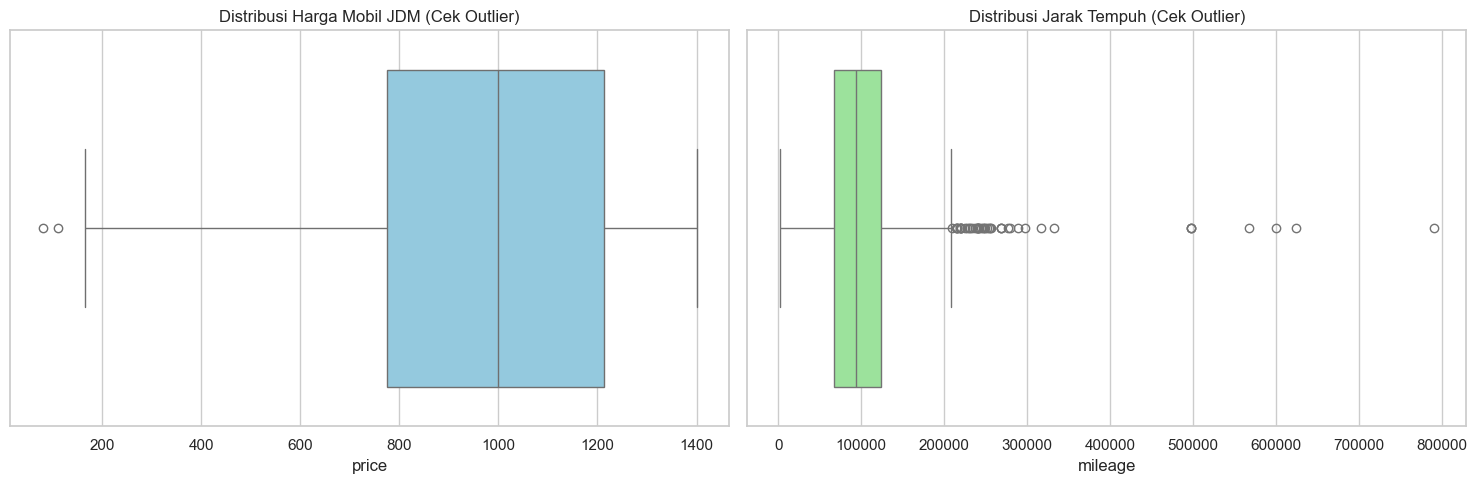

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat kanvas visualisasi dengan 2 grafik bersebelahan
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot untuk Harga
sns.boxplot(x=df['price'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Harga Mobil JDM (Cek Outlier)')

# Boxplot untuk Jarak Tempuh
sns.boxplot(x=df['mileage'], ax=axes[1], color='lightgreen')
axes[1].set_title('Distribusi Jarak Tempuh (Cek Outlier)')

plt.tight_layout()
plt.show()

In [20]:
# Fungsi dinamis untuk menghitung batas IQR dan memfilter outlier
def remove_outliers_iqr(dataframe, column):
    # Menghitung Kuartil 1 (25%) dan Kuartil 3 (75%)
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    
    # Menghitung selisih IQR
    IQR = Q3 - Q1
    
    # Menentukan batas aman bawah dan atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menyaring data agar hanya menyisakan yang berada di dalam batas aman
    df_filtered = dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]
    
    # Menampilkan laporan log
    print(f"--- Laporan Pembersihan Outlier Kolom '{column}' ---")
    print(f"Batas Bawah Normal : {lower_bound}")
    print(f"Batas Atas Normal  : {upper_bound}")
    print(f"Total baris awal   : {len(dataframe)}")
    print(f"Total baris akhir  : {len(df_filtered)}")
    print(f"Jumlah outlier yang dibuang: {len(dataframe) - len(df_filtered)}\n")
    
    return df_filtered

# Menerapkan fungsi pada dataset utama kita
df = remove_outliers_iqr(df, 'price')
df = remove_outliers_iqr(df, 'mileage')

--- Laporan Pembersihan Outlier Kolom 'price' ---
Batas Bawah Normal : 120.5
Batas Atas Normal  : 1868.5
Total baris awal   : 2318
Total baris akhir  : 2316
Jumlah outlier yang dibuang: 2

--- Laporan Pembersihan Outlier Kolom 'mileage' ---
Batas Bawah Normal : -18500.0
Batas Atas Normal  : 209500.0
Total baris awal   : 2316
Total baris akhir  : 2270
Jumlah outlier yang dibuang: 46



In [21]:
# 1. Mengecek daftar kolom dengan tipe teks (object)
kolom_kategori = df.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom kategorikal awal: {kolom_kategori}")

# 2. Menghapus kolom 'model' untuk menghindari High Cardinality
if 'model' in df.columns:
    df = df.drop(columns=['model'])
    print("\nKolom 'model' berhasil dihapus untuk efisiensi komputasi.")
    
# Update daftar kolom kategori setelah penghapusan
kolom_kategori = df.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom kategorikal yang siap di-encode: {kolom_kategori}")

Kolom kategorikal awal: ['mark', 'model', 'transmission', 'drive', 'hand_drive', 'fuel']

Kolom 'model' berhasil dihapus untuk efisiensi komputasi.
Kolom kategorikal yang siap di-encode: ['mark', 'transmission', 'drive', 'hand_drive', 'fuel']


C:\Users\HP\AppData\Local\Temp\ipykernel_20048\907503785.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  kolom_kategori = df.select_dtypes(include=['object']).columns.tolist()
C:\Users\HP\AppData\Local\Temp\ipykernel_20048\907503785.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/us

In [22]:
# drop_first=True digunakan untuk menghindari "Dummy Variable Trap" (Multikolinearitas)
df_encoded = pd.get_dummies(df, columns=kolom_kategori, drop_first=True)

# Mengecek dimensi data baru dan melihat hasilnya
print(f"Dimensi dataset setelah di-encode: {df_encoded.shape[0]} baris, {df_encoded.shape[1]} kolom")

# Menampilkan 5 baris pertama untuk memastikan teks sudah berubah menjadi angka/boolean
display(df_encoded.head())

Dimensi dataset setelah di-encode: 2270 baris, 40 kolom


,price,year,mileage,engine_capacity,mark_bmw,mark_chrysler,mark_citroen,mark_daihatsu,mark_ford,mark_gm,...,transmission_cvt,transmission_mt,drive_4wd,drive_awd,hand_drive_lhd,hand_drive_rhd,fuel_diesel,fuel_gasoline,fuel_hybrid,fuel_lpg
2,165,2005,47690,2000,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,190,2008,130661,1990,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
4,190,2006,66300,660,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
5,190,2004,81400,660,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
6,220,2010,117000,1200,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False


In [23]:
from sklearn.preprocessing import StandardScaler

# 1. Menentukan kolom numerik mana saja yang akan di-scale
kolom_numerik = ['year', 'mileage', 'engine_capacity']

# 2. Inisialisasi fungsi scaler
scaler = StandardScaler()

# 3. Menerapkan scaling pada DataFrame 'df_encoded' (hasil dari Day 5)
df_encoded[kolom_numerik] = scaler.fit_transform(df_encoded[kolom_numerik])

# 4. Mengecek hasilnya
print("Statistik kolom numerik setelah Scaling (Rata-rata mendekati 0):")
display(df_encoded[kolom_numerik].describe().round(2))

# Menampilkan 5 baris pertama DataFrame final
print("\nWajah Dataset Final Kita Saat Ini:")
display(df_encoded.head())

Statistik kolom numerik setelah Scaling (Rata-rata mendekati 0):


,year,mileage,engine_capacity
count,2270.00,2270.00,2270.00
mean,0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-7.33,-2.30,-2.75
25%,-0.53,-0.73,-0.37
50%,0.01,-0.08,-0.02
75%,0.83,0.62,0.55
max,2.46,2.75,19.95



Wajah Dataset Final Kita Saat Ini:


,price,year,mileage,engine_capacity,mark_bmw,mark_chrysler,mark_citroen,mark_daihatsu,mark_ford,mark_gm,...,transmission_cvt,transmission_mt,drive_4wd,drive_awd,hand_drive_lhd,hand_drive_rhd,fuel_diesel,fuel_gasoline,fuel_hybrid,fuel_lpg
2,165,-0.260302,-1.182687,0.916686,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,190,0.555838,0.846600,0.898281,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
4,190,0.011745,-0.727528,-1.549646,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
5,190,-0.532349,-0.358215,-1.549646,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
6,220,1.099932,0.512482,-0.555751,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
